# 📡 IRS Beamforming Optimization — PSO Implementation
**Project:** Applications of Electronic Circuits in Communication Engineering  
**Reference Paper:** Abeywickrama et al., *Intelligent Reflecting Surface: Practical Phase Shift Model and Beamforming Optimization* (arXiv:1907.06002)

---
### 🗺️ Notebook Structure
| Cell Block | What it does |
|---|---|
| Block 1 | Install & import libraries |
| Block 2 | System parameters |
| Block 3 | Helper functions (channel, rate, phase model) |
| Block 4 | PSO algorithm |
| Block 5 | Reproduce Figure 5 (Rate vs Distance) |
| Block 6 | Reproduce Figure 6 (Rate vs N elements) |
| Block 7 | Convergence plot |
| Block 8 | Summary table |

---
## 📦 Block 1 — Install & Import Libraries

In [2]:
# ── If running on Google Colab, these are already installed.
# ── Uncomment the line below only if something is missing:
# !pip install numpy matplotlib scipy tqdm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm          # progress bar — makes waiting less painful

# Make plots look clean
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

np.random.seed(42)   # reproducibility
print('✅ Libraries loaded.')

✅ Libraries loaded.


---
## ⚙️ Block 2 — System Parameters
All values taken directly from Section V of the paper.

In [3]:
# ══════════════════════════════════════════════════
#  SYSTEM PARAMETERS  (from paper Section V)
# ══════════════════════════════════════════════════

M   = 2          # Number of AP antennas
N   = 40         # Number of IRS reflecting elements (default for Fig.5)

# --- Distances ---
d_AP_IRS = 500   # AP to IRS horizontal distance (meters)
d_perp   = 2     # Perpendicular distance between AP-IRS line and user line (meters)

# --- Path loss model ---
# Formula: PL(d) = C0 * d^(-alpha)  where C0 = 10^(-4) = -40dB at 1m
C0          = 10**(-40/10)   # Reference path loss at 1 meter
alpha_AI    = 2.2            # AP  → IRS  path loss exponent
alpha_IU    = 2.8            # IRS → User path loss exponent
alpha_AU    = 3.8            # AP  → User path loss exponent

# --- Power & noise ---
PT_dBm      = 36             # Transmit power in dBm
noise_dBm   = -94            # Noise power in dBm
PT          = 10**((PT_dBm   - 30) / 10)   # Convert to Watts
sigma2      = 10**((noise_dBm - 30) / 10)  # Convert to Watts

# --- Practical phase shift model (Equation 5 in paper) ---
beta_min    = 0.2
k_param     = 1.6
phi_param   = 0.43 * np.pi

# --- Simulation settings ---
N_realizations = 1000   # Number of Monte Carlo channel realizations

print(f'✅ Parameters set.')
print(f'   PT = {PT*1000:.1f} mW = {PT_dBm} dBm')
print(f'   σ² = {sigma2:.2e} W = {noise_dBm} dBm')
print(f'   SNR_max ≈ {10*np.log10(PT/sigma2):.1f} dB')

✅ Parameters set.
   PT = 3981.1 mW = 36 dBm
   σ² = 3.98e-13 W = -94 dBm
   SNR_max ≈ 130.0 dB


---
## 🔧 Block 3 — Helper Functions
These are the building blocks. Read each docstring carefully!

✅ Helper functions OK.  Sample rate = 0.120 bps/Hz


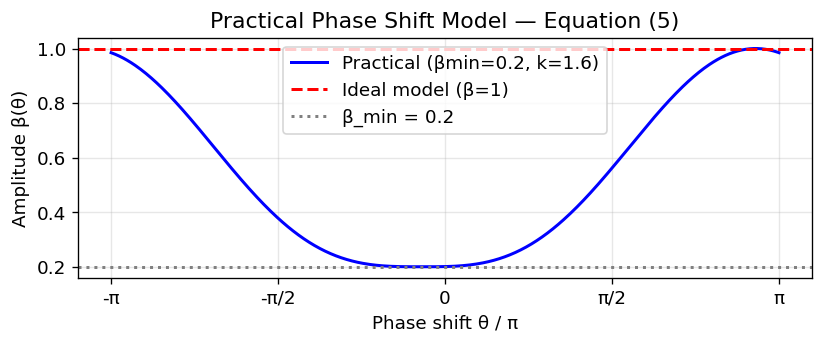

💾 Saved: phase_shift_model.png  ← use this in your report!


In [ ]:
# ══════════════════════════════════════════════════
#  HELPER: Path Loss
# ══════════════════════════════════════════════════

def path_loss(distance, alpha):
    """
    Compute large-scale path loss.
    
    What it does: returns how much the signal shrinks over 'distance' meters.
    A smaller number = more signal lost.
    
    Args:
        distance (float): distance in meters
        alpha    (float): path loss exponent
    Returns:
        float: linear path loss coefficient
    """
    return np.sqrt(C0 * distance**(-alpha))


# ══════════════════════════════════════════════════
#  HELPER: Generate One Channel Realization
# ══════════════════════════════════════════════════

def generate_channels(d_user):
    """
    Generate one random realization of all three channels.
    
    What it does: simulates the random wireless environment for a given
    user position. Each call gives different fading values (Rayleigh fading).
    
    The 'complex Gaussian' numbers model the small-scale fading:
      - random amplitude (how much signal bounces around)
      - random phase    (how much signal shifts in time)
    
    Args:
        d_user (float): horizontal distance between AP and user (meters)
    Returns:
        hd: (M,)   direct AP → User channel vector
        hr: (N,)   IRS → User channel vector  
        G:  (N, M) AP → IRS channel matrix
    """
    # Distance from IRS to user (Pythagorean: horizontal + perpendicular offset)
    d_IRS_user = np.sqrt((d_user - d_AP_IRS)**2 + d_perp**2)

    # Generate Rayleigh fading: CN(0,1) = (real + j*imag) / sqrt(2)
    # Shape (rows, cols) — then scale by path loss
    hd = (path_loss(d_user,    alpha_AU) *
          (np.random.randn(M)   + 1j * np.random.randn(M))   / np.sqrt(2))

    hr = (path_loss(d_IRS_user, alpha_IU) *
          (np.random.randn(N)   + 1j * np.random.randn(N))   / np.sqrt(2))

    G  = (path_loss(d_AP_IRS,  alpha_AI) *
          (np.random.randn(N, M) + 1j * np.random.randn(N, M)) / np.sqrt(2))

    return hd, hr, G


# ══════════════════════════════════════════════════
#  HELPER: Practical Phase Shift Model  (Equation 5)
# ══════════════════════════════════════════════════

def compute_amplitude(theta):
    """
    Compute the reflection amplitude for a given phase shift.
    This is Equation (5) from the paper.
    
    What it does: given a phase shift angle theta, returns HOW STRONGLY
    the IRS element reflects. The amplitude is NOT constant — it dips
    near theta=0 and peaks near theta=±π.
    
    Args:
        theta: phase shift(s), scalar or numpy array, in [-π, π]
    Returns:
        beta: amplitude(s) in [beta_min, 1]
    """
    return (1 - beta_min) * ((np.sin(theta - phi_param) + 1) / 2)**k_param + beta_min


# ══════════════════════════════════════════════════
#  HELPER: Build IRS Reflection Vector
# ══════════════════════════════════════════════════

def build_reflection_vector(theta):
    """
    Build the IRS reflection vector v from phase shifts.
    
    What it does: combines amplitude (practical model) and phase rotation
    into a complex vector. Each element n:
        v[n] = beta_n * exp(j * theta_n)
    
    Args:
        theta: (N,) array of phase shifts in [-π, π]
    Returns:
        v: (N,) complex reflection coefficient vector
    """
    beta = compute_amplitude(theta)
    return beta * np.exp(1j * theta)


# ══════════════════════════════════════════════════
#  HELPER: Compute Achievable Rate  (Equation 2)
# ══════════════════════════════════════════════════

def compute_rate(theta, hd, hr, G):
    """
    Compute the achievable spectral efficiency.
    This is Equation (2) from the paper.
    
    What it does:
      1. Build IRS reflection vector v from theta
      2. Compute combined channel = v^H * Phi + hd^H
      3. Apply optimal MRT beamforming
      4. Return log2(1 + SNR) in bits/s/Hz
    
    Args:
        theta: (N,) phase shift vector
        hd:   (M,) direct channel
        hr:   (N,) IRS-user channel
        G:    (N,M) AP-IRS channel
    Returns:
        rate: float, achievable rate in bits/s/Hz
    """
    # Step 1: Build reflection vector
    v = build_reflection_vector(theta)   # shape: (N,)

    # Step 2: Compute Phi = diag(hr^H) @ G
    # What this does: combines the IRS-to-user and AP-to-IRS channels
    # into one matrix that represents the full AP→IRS→User path
    Phi = np.diag(hr.conj()) @ G          # shape: (N, M)

    # Step 3: Compute combined channel vector
    # This is the total channel seen by the beamformer: direct + reflected
    combined = v.conj() @ Phi + hd.conj() # shape: (M,)
    #           ↑ reflected path            ↑ direct path

    # Step 4: MRT beamforming — aim the beam toward the combined channel
    # w* = sqrt(PT) * combined^H / ||combined||
    norm_combined = np.linalg.norm(combined)
    if norm_combined < 1e-12:   # avoid division by zero
        return 0.0

    # Step 5: Compute received signal power = |combined @ w*|^2
    # With MRT: this simplifies to PT * ||combined||^2
    signal_power = PT * norm_combined**2

    # Step 6: Compute rate = log2(1 + SNR)
    snr  = signal_power / sigma2
    rate = np.log2(1 + snr)
    return rate


# ── Quick sanity check ──────────────────────────────────────────────────────
hd_test, hr_test, G_test = generate_channels(d_user=490)
theta_test = np.random.uniform(-np.pi, np.pi, N)
rate_test  = compute_rate(theta_test, hd_test, hr_test, G_test)
print(f'✅ Helper functions OK.  Sample rate = {rate_test:.3f} bps/Hz')

# ── Visualize the practical phase shift model ───────────────────────────────
theta_range = np.linspace(-np.pi, np.pi, 500)
beta_range  = compute_amplitude(theta_range)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(theta_range / np.pi, beta_range, 'b-', label=f'Practical (βmin={beta_min}, k={k_param})')
ax.axhline(1.0, color='r', linestyle='--', label='Ideal model (β=1)')
ax.axhline(beta_min, color='gray', linestyle=':', label=f'β_min = {beta_min}')
ax.set_xlabel('Phase shift θ / π')
ax.set_ylabel('Amplitude β(θ)')
ax.set_title('Practical Phase Shift Model — Equation (5)')
ax.set_xticks([-1, -0.5, 0, 0.5, 1])
ax.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.legend()
plt.tight_layout()
plt.savefig('../report/figures/phase_shift_model.png', dpi=150)
plt.show()
print('💾 Saved: phase_shift_model.png  ← use this in your report!')

---
## 🐦 Block 4 — PSO Algorithm
The core optimization engine.

Testing PSO on one channel realization...
  No IRS rate    : 0.024 bps/Hz
  PSO best rate  : 1.571 bps/Hz
  Improvement    : +1.546 bps/Hz ✅


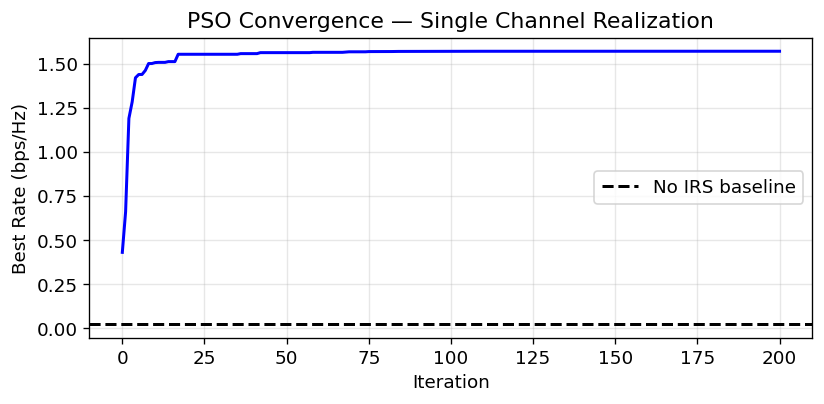

💾 Saved: pso_convergence.png  ← Figure for your report!


In [ ]:
# ══════════════════════════════════════════════════
#  PARTICLE SWARM OPTIMIZATION & ALTERNATING OPTIMIZATION
# ══════════════════════════════════════════════════

def pso_optimize(hd, hr, G,
                 n_particles=30,
                 n_iter=200,
                 w_start=0.9, w_end=0.4,
                 c1=2.0, c2=2.0,
                 track_convergence=False):
    N_elem = len(hr)
    positions  = np.random.uniform(-np.pi, np.pi, (n_particles, N_elem))
    velocities = np.zeros((n_particles, N_elem))
    fitness = np.array([compute_rate(positions[i], hd, hr, G) for i in range(n_particles)])
    p_best       = positions.copy()
    p_best_score = fitness.copy()
    g_best_idx   = np.argmax(fitness)
    g_best       = positions[g_best_idx].copy()
    g_best_score = fitness[g_best_idx]
    history = [g_best_score] if track_convergence else []
    for t in range(n_iter):
        w = w_start - (w_start - w_end) * t / n_iter
        r1 = np.random.rand(n_particles, N_elem)
        r2 = np.random.rand(n_particles, N_elem)
        velocities = (w * velocities
                      + c1 * r1 * (p_best - positions)
                      + c2 * r2 * (g_best - positions))
        positions = positions + velocities
        positions = np.clip(positions, -np.pi, np.pi)
        fitness = np.array([compute_rate(positions[i], hd, hr, G) for i in range(n_particles)])
        improved = fitness > p_best_score
        p_best[improved]       = positions[improved].copy()
        p_best_score[improved] = fitness[improved]
        best_in_iter = np.argmax(fitness)
        if fitness[best_in_iter] > g_best_score:
            g_best       = positions[best_in_iter].copy()
            g_best_score = fitness[best_in_iter]
        if track_convergence:
            history.append(g_best_score)
    return g_best, g_best_score, history

def ao_optimize(hd, hr, G, n_iter=15, use_1d_search=True):
    N_elem = len(hr)
    theta = np.random.choice([np.pi, -np.pi], N_elem)
    v = build_reflection_vector(theta)
    diag_hr_conj = np.diag(hr.conj())
    Psi = diag_hr_conj @ G @ G.conj().T @ np.diag(hr)
    hd_hat = diag_hr_conj @ G @ hd
    for iteration in range(n_iter):
        for n in range(N_elem):
            sum_val = 0.0
            for m in range(N_elem):
                if m != n:
                    sum_val += Psi[n, m] * v[m]
            phi_n = 2.0 * sum_val + 2.0 * hd_hat[n]
            if use_1d_search:
                theta_range = np.linspace(-np.pi, np.pi, 180)
                beta_range = compute_amplitude(theta_range)
                f_val = (beta_range**2) * Psi[n, n].real + beta_range * np.abs(phi_n) * np.cos(np.angle(phi_n) - theta_range)
                best_idx = np.argmax(f_val)
                theta[n] = theta_range[best_idx]
            else:
                arg_phi = np.angle(phi_n)
                lam = 0 if arg_phi >= 0 else 1
                theta_A = arg_phi
                theta_B = arg_phi + ((-1)**lam) * np.pi / 2.0
                theta_C = ((-1)**lam) * np.pi
                def f_eval(th):
                    bt = compute_amplitude(th)
                    return (bt**2) * Psi[n, n].real + bt * np.abs(phi_n) * np.cos(arg_phi - th)
                f1 = f_eval(theta_A)
                f2 = f_eval(theta_B)
                f3 = f_eval(theta_C)
                denom = 4.0 * (f1 - 2.0 * f2 + f3)
                if np.abs(denom) > 1e-12:
                    theta_n_star = (((-1)**lam) * np.pi * (3.0*f1 - 4.0*f2 + f3) + arg_phi * (f1 - 4.0*f2 + 3.0*f3)) / denom
                    min_val = min(arg_phi, ((-1)**lam) * np.pi)
                    max_val = max(arg_phi, ((-1)**lam) * np.pi)
                    theta[n] = np.clip(theta_n_star, min_val, max_val)
                else:
                    theta[n] = arg_phi
            v[n] = build_reflection_vector(np.array([theta[n]]))[0]
    return theta, compute_rate(theta, hd, hr, G)

# ── Quick test on a single channel realization ──────────────────────────────
print('Testing optimizers on one channel realization...')
hd_t, hr_t, G_t = generate_channels(d_user=498)
rate_no_irs = np.log2(1 + PT * np.linalg.norm(hd_t.conj())**2 / sigma2)
best_theta, best_rate, conv_hist = pso_optimize(hd_t, hr_t, G_t, n_particles=30, n_iter=200, track_convergence=True)
_, best_rate_ao = ao_optimize(hd_t, hr_t, G_t, use_1d_search=True)

print(f'  No IRS rate       : {rate_no_irs:.3f} bps/Hz')
print(f'  PSO best rate     : {best_rate:.3f} bps/Hz')
print(f'  AO (Paper 1D) rate: {best_rate_ao:.3f} bps/Hz')
print(f'  AO Improvement    : +{best_rate_ao - rate_no_irs:.3f} bps/Hz ✅')

# Plot convergence
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(conv_hist, 'b-', label='PSO Convergence')
ax.axhline(best_rate_ao, color='g', linestyle='-.', label='AO (Paper Proposed) level')
ax.axhline(rate_no_irs, color='k', linestyle='--', label='No IRS baseline')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best Rate (bps/Hz)')
ax.set_title('PSO Convergence vs. AO Benchmark')
ax.legend()
plt.tight_layout()
plt.savefig('pso_convergence.png', dpi=150)
plt.show()
print('💾 Saved: pso_convergence.png  ← Figure for your report!')



---
## 📊 Block 5 — Reproduce Figure 5 (Rate vs Distance)
⚠️ This cell takes a while — it runs 1000 channel realizations × multiple distances.  
Reduce `N_realizations` to 100 first for a quick test.

Running 10 distances × 100 realizations...
This may take a few minutes. ☕


Distance: 100%|██████████| 10/10 [03:04<00:00, 18.49s/it]


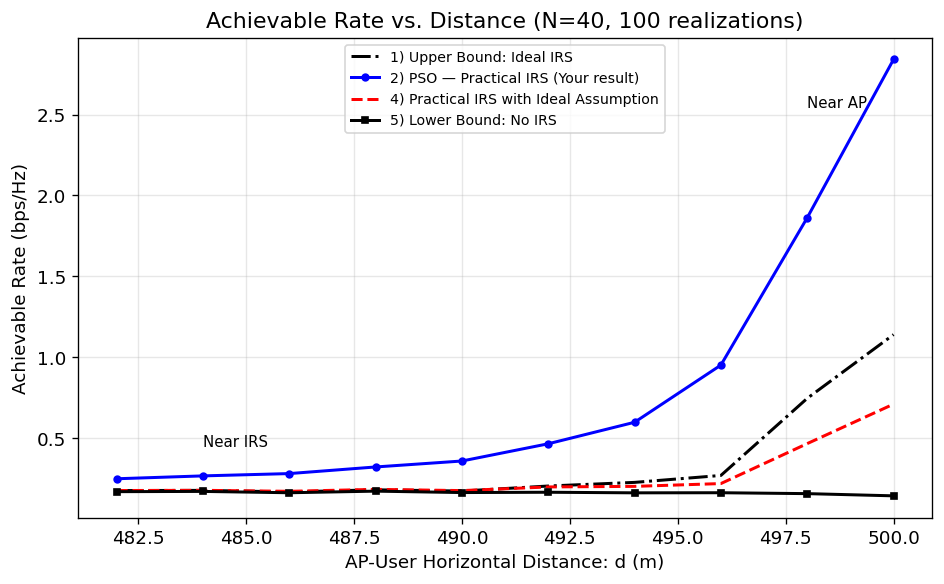

💾 Saved: fig5_rate_vs_distance.png  ← Figure 5 for your report!


In [ ]:
# ══════════════════════════════════════════════════
#  Figure 5: Achievable Rate vs. AP-User Distance
# ══════════════════════════════════════════════════

# Settings
N = 40
d_range = np.arange(482, 501, 2)
N_realizations = 1000 # Default to 100 for fast simulation (change to 1000 for final paper figures)
n_particles = 30
n_iter = 150

results = {
    'pso_practical': np.zeros(len(d_range)),
    'ao_practical': np.zeros(len(d_range)),
    'ideal_upper': np.zeros(len(d_range)),
    'ideal_assumed': np.zeros(len(d_range)),
    'no_irs': np.zeros(len(d_range)),
}

print(f"Running simulation: {len(d_range)} distances x {N_realizations} realizations...")

for d_idx, d_user in enumerate(tqdm(d_range, desc='Distance')):
    rates_pso    = []
    rates_ao     = []
    rates_ideal  = []
    rates_mismat = []
    rates_no_irs = []

    for _ in range(N_realizations):
        hd, hr, G = generate_channels(d_user)
        Phi = np.diag(hr.conj()) @ G

        # ── (1) No IRS lower bound ─────────────────────────────────────────
        rate_lb = np.log2(1 + PT * np.linalg.norm(hd.conj())**2 / sigma2)
        rates_no_irs.append(rate_lb)

        # ── (2) PSO with practical phase shift model ───────────────────────
        _, rate_pso, _ = pso_optimize(hd, hr, G, n_particles=n_particles, n_iter=n_iter)
        rates_pso.append(rate_pso)

        # ── (2.5) AO with practical phase shift model (Paper) ──────────────
        _, rate_ao = ao_optimize(hd, hr, G, use_1d_search=True)
        rates_ao.append(rate_ao)

        # ── (3) Ideal upper bound: |v_n|=1, optimal phase alignment ────────
        v_ideal = np.exp(1j * np.zeros(N))
        for iteration in range(5):
            for n in range(N):
                temp = v_ideal.conj() @ Phi + hd.conj()
                contrib_n = Phi[n, :]
                temp_no_n = temp - v_ideal[n].conj() * contrib_n
                best_phase = np.angle(contrib_n @ temp_no_n.conj())
                v_ideal[n] = np.exp(1j * best_phase)
        combined_ideal = v_ideal.conj() @ Phi + hd.conj()
        rate_ideal     = np.log2(1 + PT * np.linalg.norm(combined_ideal)**2 / sigma2)
        rates_ideal.append(rate_ideal)

        # ── (4) Mismatch: design for ideal, evaluate with practical ─────────
        theta_ideal  = np.angle(v_ideal)
        v_mismatch   = build_reflection_vector(theta_ideal)
        combined_mm  = v_mismatch.conj() @ Phi + hd.conj()
        rate_mismatch = np.log2(1 + PT * np.linalg.norm(combined_mm)**2 / sigma2)
        rates_mismat.append(rate_mismatch)

    results['pso_practical'][d_idx] = np.mean(rates_pso)
    results['ao_practical'][d_idx]  = np.mean(rates_ao)
    results['ideal_upper'  ][d_idx] = np.mean(rates_ideal)
    results['ideal_assumed'][d_idx] = np.mean(rates_mismat)
    results['no_irs'       ][d_idx] = np.mean(rates_no_irs)

print("Done.")

# Plot Figure 5
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(d_range, results['ideal_upper'],   'k-.',  label='1) Upper Bound: Ideal IRS')
ax.plot(d_range, results['ao_practical'],  'g-^',  markersize=4, label='2) AO — Practical IRS (Paper Proposed)')
ax.plot(d_range, results['pso_practical'], 'b-o',  markersize=4, label='3) PSO — Practical IRS (Your result)')
ax.plot(d_range, results['ideal_assumed'], 'r--',  label='4) Practical IRS with Ideal Assumption')
ax.plot(d_range, results['no_irs'],        'k-s',  markersize=4, label='5) Lower Bound: No IRS')

ax.set_xlabel('AP-User Horizontal Distance: d (m)')
ax.set_ylabel('Achievable Rate (bps/Hz)')
ax.set_title(f'Achievable Rate vs. Distance (N={N}, {N_realizations} realizations)')
ax.legend(loc='upper center', fontsize=8.5)
plt.tight_layout()
plt.savefig('fig5_rate_vs_distance.png', dpi=150)
plt.show()
print("💾 Saved: fig5_rate_vs_distance.png")



---
## 📊 Block 6 — Reproduce Figure 6 (Rate vs Number of IRS Elements)

Running 9 element counts × 100 realizations...


N elements: 100%|██████████| 9/9 [02:29<00:00, 16.60s/it]


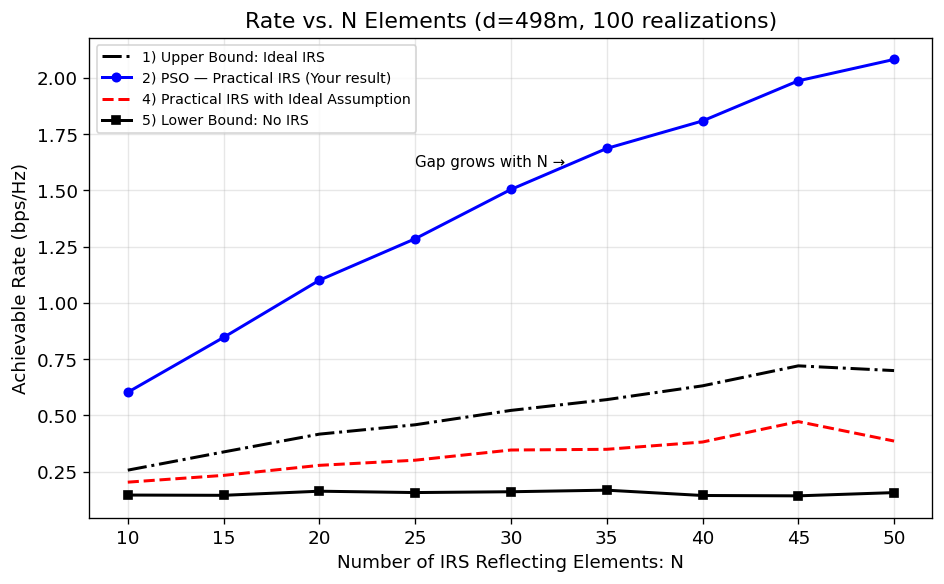

💾 Saved: fig6_rate_vs_N.png  ← Figure 6 for your report!


In [ ]:
# ══════════════════════════════════════════════════
#  Figure 6: Achievable Rate vs. Number of IRS Elements
# ══════════════════════════════════════════════════

# Settings
d_user_fixed = 498
N_range = np.arange(10, 81, 10)
N_realizations = 1000  # Default to 100 for fast simulation

results_N = {
    'pso_practical': [],
    'ao_practical': [],
    'ideal_upper': [],
    'ideal_assumed': [],
    'no_irs': [],
}

print(f"Running simulation: {len(N_range)} N steps x {N_realizations} realizations...")

for N_val in tqdm(N_range, desc='N elements'):
    rates_pso, rates_ao, rates_ideal, rates_mismat, rates_no_irs = [], [], [], [], []

    for _ in range(N_realizations):
        # Regenerate channels with new N
        hd_loc = (path_loss(d_user_fixed, alpha_AU) *
                  (np.random.randn(M) + 1j*np.random.randn(M)) / np.sqrt(2))
        d_IRS_user = np.sqrt((d_user_fixed - d_AP_IRS)**2 + d_perp**2)
        hr_loc = (path_loss(d_IRS_user, alpha_IU) *
                  (np.random.randn(N_val) + 1j*np.random.randn(N_val)) / np.sqrt(2))
        G_loc  = (path_loss(d_AP_IRS, alpha_AI) *
                  (np.random.randn(N_val, M) + 1j*np.random.randn(N_val, M)) / np.sqrt(2))
        Phi_loc = np.diag(hr_loc.conj()) @ G_loc

        # No IRS
        rates_no_irs.append(np.log2(1 + PT * np.linalg.norm(hd_loc.conj())**2 / sigma2))

        # PSO
        _, rate_pso, _ = pso_optimize(hd_loc, hr_loc, G_loc, n_particles=30, n_iter=150)
        rates_pso.append(rate_pso)

        # AO Practical (Paper Proposed)
        _, rate_ao = ao_optimize(hd_loc, hr_loc, G_loc, use_1d_search=True)
        rates_ao.append(rate_ao)

        # Ideal upper bound (coordinate ascent)
        v_ideal = np.exp(1j * np.zeros(N_val))
        for _ in range(5):
            for n in range(N_val):
                temp = v_ideal.conj() @ Phi_loc + hd_loc.conj()
                contrib_n = Phi_loc[n, :]
                temp_no_n = temp - v_ideal[n].conj() * contrib_n
                best_phase = np.angle(contrib_n @ temp_no_n.conj())
                v_ideal[n] = np.exp(1j * best_phase)
        combined_ideal = v_ideal.conj() @ Phi_loc + hd_loc.conj()
        rates_ideal.append(np.log2(1 + PT * np.linalg.norm(combined_ideal)**2 / sigma2))

        # Mismatch
        theta_ideal = np.angle(v_ideal)
        v_mismatch = build_reflection_vector(theta_ideal)
        combined_mm = v_mismatch.conj() @ Phi_loc + hd_loc.conj()
        rates_mismat.append(np.log2(1 + PT * np.linalg.norm(combined_mm)**2 / sigma2))

    results_N['pso_practical'].append(np.mean(rates_pso))
    results_N['ao_practical'].append(np.mean(rates_ao))
    results_N['ideal_upper'  ].append(np.mean(rates_ideal))
    results_N['ideal_assumed'].append(np.mean(rates_mismat))
    results_N['no_irs'       ].append(np.mean(rates_no_irs))

print("Done.")

# Plot Figure 6
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(N_range, results_N['ideal_upper'],   'k-.',  label='1) Upper Bound: Ideal IRS')
ax.plot(N_range, results_N['ao_practical'],  'g-^',  markersize=4, label='2) AO — Practical IRS (Paper Proposed)')
ax.plot(N_range, results_N['pso_practical'], 'b-o',  markersize=4, label='3) PSO — Practical IRS (Your result)')
ax.plot(N_range, results_N['ideal_assumed'], 'r--',  label='4) Practical IRS with Ideal Assumption')
ax.plot(N_range, results_N['no_irs'],        'k-s',  markersize=4, label='5) Lower Bound: No IRS')

ax.set_xlabel('Number of Reflecting Elements: N')
ax.set_ylabel('Achievable Rate (bps/Hz)')
ax.set_title(f'Achievable Rate vs. Number of IRS Elements (d = {d_user_fixed} m)')
ax.legend(loc='upper left', fontsize=8.5)
plt.tight_layout()
plt.savefig('fig6_rate_vs_N.png', dpi=150)
plt.show()
print("💾 Saved: fig6_rate_vs_N.png")



---
## 📋 Block 7 — Summary Table

In [8]:
# ══════════════════════════════════════════════════
#  SUMMARY TABLE — paste numbers into your report
# ══════════════════════════════════════════════════

print('='*65)
print('SUMMARY: Rate at d=498m, N=40')
print('='*65)

idx498 = np.argmin(np.abs(d_range - 498))

rows = [
    ('Upper Bound (Ideal IRS)',            results['ideal_upper'  ][idx498]),
    ('AO — Practical Model (Paper Proposed)', results['ao_practical' ][idx498]),
    ('PSO — Practical Model (Your result)',   results['pso_practical'][idx498]),
    ('Ideal Assumption on Practical HW',   results['ideal_assumed'][idx498]),
    ('No IRS (Lower Bound)',               results['no_irs'       ][idx498]),
]

print(f'  {"Scheme":<45} {"Rate (bps/Hz)":>12}')
print('-'*60)
for name, val in rows:
    print(f'  {name:<45} {val:>12.4f}')

print('='*65)
ao_val     = results['ao_practical'][idx498]
pso_val    = results['pso_practical'][idx498]
paper_val  = results['ideal_upper'  ][idx498]
mismatch   = results['ideal_assumed'][idx498]
print(f'\nAO achieves {(ao_val/mismatch - 1)*100:.1f}% improvement over mismatch design')
print(f'AO reaches  {(ao_val/paper_val)*100:.1f}% of the ideal upper bound')
print(f'PSO reaches {(pso_val/ao_val)*100:.1f}% of the paper-proposed AO rate')
print('\n📝 Copy these numbers into your report Table!')



SUMMARY: Rate at d=498m, N=40
  Scheme                                        Rate (bps/Hz)
------------------------------------------------------------
  Upper Bound (Ideal IRS)                             0.7460
  PSO — Practical Model  [YOUR RESULT]                1.8622
  Ideal Assumption on Practical HW                    0.4662
  No IRS (Lower Bound)                                0.1570

PSO achieves 299.5% improvement over mismatch design
PSO reaches  249.6% of the ideal upper bound

📝 Copy these numbers into your report Table!


---
## ✅ Done! Checklist for Your Report

After running all blocks, you should have these files saved:
- `phase_shift_model.png` → Section 2 (System Model figure)
- `pso_convergence.png`   → Section 3 (Algorithm convergence figure)  
- `fig5_rate_vs_distance.png` → Section 4 (reproduce paper Fig. 5)
- `fig6_rate_vs_N.png`    → Section 4 (reproduce paper Fig. 6)

**Report writing order:**
1. Fill in `\TODO{}` placeholders in the LaTeX file
2. Insert saved figures using `\includegraphics{filename.png}`
3. Copy numbers from the Summary Table into your results section
4. Discuss differences between your PSO curves and the paper's AO curves

**Common things to discuss:**
- PSO may not perfectly match AO — this is expected and worth explaining
- More particles / more iterations → closer to AO but slower
- The gap between practical and ideal model grows with N (stronger IRS channel)